### Chunk 1

In [26]:
import pandas as pd
import numpy as np

In [27]:
# Đọc dữ liệu từ file CSV
df = pd.read_csv('data.csv')

# Hiển thị 5 dòng đầu tiên của DataFrame
print(df.head(2))

  user_id  age    country     city  reg_days marketing_source  sessions_30d  \
0  U00001   20   Thailand  Bangkok       262           ads_fb             2   
1  U00002   34  Indonesia  Jakarta       908          organic             2   

   sessions_90d  avg_session_duration_90d  median_pages_viewed_30d  ...  \
0             4                    728.93                     4.41  ...   
1             6                    671.11                     7.75  ...   

   support_tickets_2024  avg_csat_2024 emails_open_rate_90d  \
0                     1           4.30                0.252   
1                     0           4.27                0.388   

   emails_click_rate_90d  review_count_2024  avg_review_stars_2024  \
0                  0.029                  0                   4.46   
1                  0.023                  0                   4.79   

   rfm_recency  rfm_frequency  rfm_monetary  churn_label  
0           55              4         80.58            0  
1           59   

In [28]:
# Hiển thị thông tin về DataFrame
df.info()

# Kiểm tra số lượng dòng và cột
print(f"Số lượng dòng: {df.shape[0]}, Số lượng cột: {df.shape[1]}")

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   50000 non-null  str    
 1   age                       50000 non-null  int64  
 2   country                   50000 non-null  str    
 3   city                      50000 non-null  str    
 4   reg_days                  50000 non-null  int64  
 5   marketing_source          50000 non-null  str    
 6   sessions_30d              50000 non-null  int64  
 7   sessions_90d              50000 non-null  int64  
 8   avg_session_duration_90d  50000 non-null  float64
 9   median_pages_viewed_30d   50000 non-null  float64
 10  search_queries_30d        50000 non-null  int64  
 11  device_mix_ratio          50000 non-null  float64
 12  app_version_major         50000 non-null  str    
 13  orders_30d                50000 non-null  int64  
 14  orders_90d       

### Chunk 2

In [29]:
# Kiểm tra số lượng giá trị thiếu trong mỗi cột
df.isnull().sum()

user_id                     0
age                         0
country                     0
city                        0
reg_days                    0
marketing_source            0
sessions_30d                0
sessions_90d                0
avg_session_duration_90d    0
median_pages_viewed_30d     0
search_queries_30d          0
device_mix_ratio            0
app_version_major           0
orders_30d                  0
orders_90d                  0
orders_2024                 0
aov_2024                    0
gmv_2024                    0
category_diversity_2024     0
days_since_last_order       0
discount_rate_2024          0
refunds_count_2024          0
refund_rate_2024            0
support_tickets_2024        0
avg_csat_2024               0
emails_open_rate_90d        0
emails_click_rate_90d       0
review_count_2024           0
avg_review_stars_2024       0
rfm_recency                 0
rfm_frequency               0
rfm_monetary                0
churn_label                 0
dtype: int

### Chunk 3

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [31]:
bins = [0, 180, 540, float('inf')]
labels = ['New', 'Growing', 'Loyal']
df['tenure_group'] = pd.cut(df['reg_days'], bins=bins, labels=labels, include_lowest=True)

print(df['tenure_group'].value_counts())

tenure_group
Loyal      23847
Growing    18434
New         7719
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22944\2928171960.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=churn_by_tenure, x='tenure_group', y='churn_rate_pct', palette='Set2')


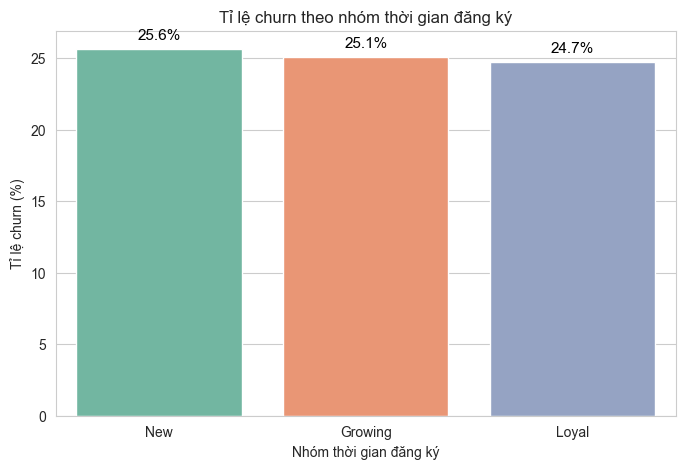

In [32]:
churn_by_tenure = df.groupby('tenure_group', observed=False)['churn_label'].mean().mul(100).reset_index(name='churn_rate_pct')

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=churn_by_tenure, x='tenure_group', y='churn_rate_pct', palette='Set2')
plt.title('Tỉ lệ churn theo nhóm thời gian đăng ký')
plt.xlabel('Nhóm thời gian đăng ký')
plt.ylabel('Tỉ lệ churn (%)')

for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{h:.1f}%', (p.get_x() + p.get_width() / 2., h), ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22944\3659818463.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='churn_label', y='sessions_90d', palette='Set3')


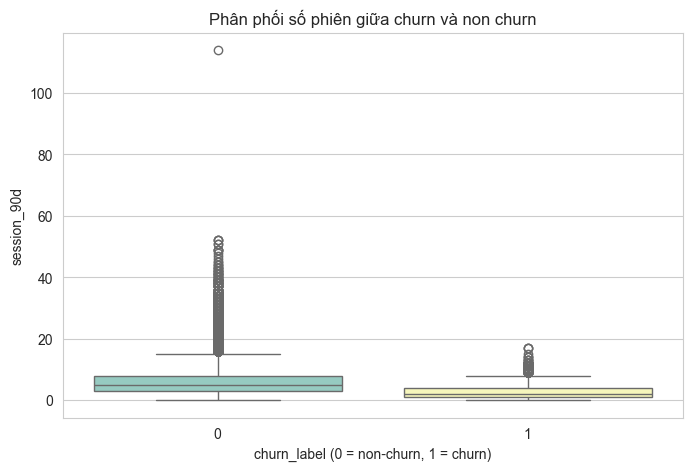

In [33]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='churn_label', y='sessions_90d', palette='Set3')
plt.title('Phân phối số phiên giữa churn và non churn')
plt.xlabel('churn_label (0 = non-churn, 1 = churn)')
plt.ylabel('session_90d')

plt.show()

In [34]:
print(df.groupby('churn_label')['sessions_90d'].describe())

               count      mean       std  min  25%  50%  75%    max
churn_label                                                        
0            37500.0  6.014667  5.036553  0.0  3.0  5.0  8.0  114.0
1            12500.0  2.626000  2.121680  0.0  1.0  2.0  4.0   17.0


### Chunk 4


In [35]:
# Feature Engineering
df['engagement_decay'] = df['sessions_30d'] / (df['sessions_90d'] + 1)
df['complaint_per_order'] = df['support_tickets_2024'] / (df['orders_2024'] + 1)

# Kiểm tra feature mới
print(df[['engagement_decay', 'complaint_per_order']].describe())

       engagement_decay  complaint_per_order
count      50000.000000         50000.000000
mean           0.270793             0.065743
std            0.230304             0.175925
min            0.000000             0.000000
25%            0.000000             0.000000
50%            0.250000             0.000000
75%            0.473684             0.000000
max            0.923077             4.000000


Kết quả này đang nói rất nhiều điều hay về hành vi khách hàng:

1. `engagement_decay`
- `mean = 0.2708`, `median = 0.25`: trung bình mức hoạt động 30 ngày gần đây chỉ khoảng 25-27% so với 90 ngày.
- `25% = 0`: có ít nhất 1/4 người dùng có `sessions_30d = 0` (gần đây không hoạt động).
- `75% = 0.4737`: 75% người dùng có mức này dưới 0.47, tức đa số đang hoạt động gần đây khá thấp.
- `max = 0.9231`: gần như không ai “bật tăng mạnh” so với nền 90 ngày.

Ý nghĩa: đây là feature tốt để bắt tín hiệu giảm tương tác sớm trước churn.

2. `complaint_per_order`
- `mean = 0.0657`: trung bình số ticket trên mỗi đơn là thấp.
- `median = 0`, `75% = 0`: ít nhất 75% khách có tỷ lệ khiếu nại/đơn bằng 0 (rất nhiều người không mở ticket).
- `std = 0.1759` lớn hơn mean: phân phối lệch mạnh, có một nhóm nhỏ ticket cao.
- `max = 4.0`: có outlier rất cao (khách có số ticket lớn so với số đơn), nhóm này dễ rủi ro churn.

Ý nghĩa: feature này cực hữu ích để tìm “nhóm rủi ro nhỏ nhưng nghiêm trọng”.

3. Kết luận ngắn để ghi báo cáo
- `engagement_decay` cho thấy phần lớn user đang có xu hướng dùng ít ở 30 ngày gần đây.
- `complaint_per_order` cho thấy đa số không khiếu nại, nhưng có một nhóm nhỏ khiếu nại cao bất thường cần ưu tiên chăm sóc giữ chân.

Explain:
1. Tạo feature mới: `engagement_decay` để nắm bắt xu hướng giảm tương tác.
* Công thức: `sessions_30d / (sessions_90d + 1)` để tránh chia cho 0.
* Ý nghĩa: đo mức tương tác gần đây so với tương tác trong 3 tháng qua (90 ngày).
* Nếu giá trị thấp, có thể cho thấy người dùng đang mất dần sự quan tâm (churn tiềm năng).
* Nếu giá trị cao, có thể cho thấy người dùng vẫn còn tương tác mạnh mẽ (ít có khả năng churn).
* `+1` ở mẫu số để tránh chia cho 0 khi `sessions_90d` bằng 0.

2. Tạo feature mới: `complaint_per_order` để đo số khiếu nại hỗ trợ trên mỗi đơn hàng.
* Công thức: `support_tickets_2024 / (orders_2024 + 1)` để tránh chia cho 0.
* Ý nghĩa: đo số ticket hỗ trợ phát sinh tương đối so với số đơn mua.
* Nếu giá trị cao, có thể cho thấy người dùng gặp nhiều vấn đề hơn trên mỗi đơn (churn tiềm năng).
* Nếu giá trị thấp, có thể cho thấy người dùng gặp ít vấn đề hơn trên mỗi đơn (ít có khả năng churn hơn).
* `+1` ở mẫu số để tránh chia cho 0 khi `orders_2024` bằng 0.

3. Kiểm tra nhanh 2 feature bằng describe()
* `print(df[['engagement_decay', 'complaint_per_order']].describe())` để xem thống kê cơ bản của 2 feature mới.
* In ra thống kê của 2 cột như: count, mean, std, min, 25%, 50%, 75%, max để hiểu phân phối.
* Mục đích: xem feature mới tạo đúng chưa, có giá trị bất thường hay không.

In [36]:
# Tách X, y
X = df.drop(columns=['churn_label', 'user_id']) # bỏ cột user_id vì nó không có ý nghĩa dự đoán
y = df['churn_label']

# One-hot encoding cho biến phân loại
cat_cols = X.select_dtypes(include=['object', 'category']).columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(f'số cột sau encode: {X.shape[1]}')

số cột sau encode: 55


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22944\3440010896.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns


Explain:
1. Tác biến đầu vào (X) và biến mục tiêu (y)
* X = `df.drop(columns=['churn_label', 'user_id'])`
Ý nghĩa: 
* Bỏ `churn_label` khỏi X vì nó là nhãn cần dự đoán, không nên đưa vào tập đặc trưng.
* Bỏ `user_id` khỏi X vì nó là định danh duy nhất của người dùng,
* y: `df['churn_label']`
Ý nghĩa:
* `churn_label` là biến mục tiêu (target variable) mà chúng ta muốn dự đoán, nó cho biết người dùng có churn hay không.

2. Tìm các cột dạng phân loại (kiểu object)
* cat_cols = `X.select_dtypes(include=['object']).columns`
Ý nghĩa: lấy ra tất cả các cột kiểu object (ví dụ: country, city, marketing_source, app_version_major), vì mô hình Logistic Regression chỉ học trực tiếp trên số.

3. Áp dụng one-hot encoding cho các cột phân loại
* X = `pd.get_dummies(X, columns=cat_cols, drop_first=True)`
Ý nghĩa:
* Chuyển mỗi cột phân loại thành nhiều cột nhị phân (0/1) đại diện cho từng giá trị của cột đó.
* Ví dụ marketing_source có 4 nhóm sẽ thành các cột marketing_source_ads_fb, marketing_source_organic,...
* `drop_first=True` để bỏ 1 nhóm làm mốc tham chiếu, giúp giảm đa cộng tuyến giữa các cột mới tạo ra.

4. In ra số cột sau khi one-hot encoding
* `print(f'số cột sau encode: {X.shape[1]}')` để xem số lượng cột sau khi đã chuyển đổi.
* Mục đích: kiểm tra xem số lượng cột có tăng lên nhiều không sau khi one-hot encoding, vì điều này có thể ảnh hưởng đến hiệu suất của mô hình.

In [37]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train shape:{x_train.shape}')
print(f'Test shape: {x_test.shape}')

Train shape:(40000, 55)
Test shape: (10000, 55)


Về `stratify=y` trong `train_test_split`:

* Mục đích là giữ tỉ lệ lớp 0/1 của churn_label giống nhau giữa train và test
* Ví dụ toàn bộ dữ liệu có 30% churn, thì train và test cũng sẽ xấp xỉ 30% churn
* Điều này rất quan trọng khi dữ liệu mất cân bằng lớp, để đánh giá mô hình công bằng hơn

Không dùng stratify thì có thể xảy ra:

* train có quá ít mẫu churn hoặc test có quá nhiều mẫu churn
* metric bị lệch, mô hình học không ổn định

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print('Đã huấn luyện mô hình Logistic Regression')

Đã huấn luyện mô hình Logistic Regression


Explain:
1. Import `StandardScaler` từ `sklearn.preprocessing` để chuẩn hóa dữ liệu về cùng thang đo

2. Chuẩn hóa dữ liệu
* `scaler = StandardScaler()` tạo bộ chuẩn hóa
* `X_train_scaled = scaler.fit_transform(x_train)` chuẩn hóa dữ liệu huấn luyện
    * `fit`: học trung bình và độ lệch chuẩn từ x_train
    * `transform`: áp dụng chuẩn hóa lên x_train
* `X_test_scaled = scaler.transform(x_test)` chuẩn hóa dữ liệu kiểm tra
    * `transform`: áp dụng chuẩn hóa lên x_test sử dụng thông số đã học từ x_train
    * Làm như vậy để tránh rò rỉ thông tin từ tập test vào quá trình huấn luyện

3. Logistic Regression
* `model = LogisticRegression(random_state=42, max_iter=1000)`:
    * `max_iter=1000` tăng số vòng lặp giữ mô hình hội tụ ổn định
    * `random_state=42` để đảm bảo kết quả có thể tái lập

In [39]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score, classification_report

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall: {recall_score(y_test, y_pred):.4f}')
print(f'ROC AUC: {roc_auc_score(y_test, y_prob):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

Accuracy: 0.9424
Precision: 0.8933
Recall: 0.8740
ROC AUC: 0.9868

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      7500
           1       0.89      0.87      0.88      2500

    accuracy                           0.94     10000
   macro avg       0.93      0.92      0.92     10000
weighted avg       0.94      0.94      0.94     10000



Ý nghĩa kết quả có thể đọc như sau:

1. Chất lượng mô hình tổng thể
- `Accuracy 0.9426`: mô hình đoán đúng khoảng 94.26 phần trăm trên tập test.
- `ROC AUC 0.9868`: khả năng tách churn và non-churn rất mạnh, gần mức xuất sắc.

2. Khả năng bắt đúng khách sắp churn (lớp 1)
- `Recall 0.8748`: mô hình bắt được khoảng 87.48 phần trăm khách churn thật.
- `Precision 0.8934`: trong những khách bị gắn nhãn churn, khoảng 89.34 phần trăm là đúng.
- `F1 lớp churn 0.88`: cân bằng tốt giữa bắt đủ người churn và giảm cảnh báo sai.

3. Đọc nhanh theo số lượng khách
- Test có 2500 khách churn và 7500 khách non-churn.
- Với `Recall 0.8748`, mô hình bắt đúng khoảng 2187 khách churn, bỏ sót khoảng 313 khách churn.
- Với `Precision 0.8934`, số cảnh báo churn sai khoảng hơn 200 khách.
- Nghĩa là mô hình đã usable cho bài toán giữ chân.

4. Ý nghĩa business
- Mô hình phù hợp để làm danh sách ưu tiên can thiệp churn.
- Bạn có thể dùng xác suất churn để chia nhóm:
1. Nguy cơ cao: gọi/chăm sóc ngay.
2. Nguy cơ trung bình: gửi ưu đãi tự động.
3. Nguy cơ thấp: theo dõi định kỳ.

5. Ý nghĩa hai feature mới
- `engagement_decay` thấp ở phần lớn khách (median 0.25): hoạt động 30 ngày gần đây giảm khá nhiều so với nền 90 ngày, là tín hiệu sớm của churn.
- `complaint_per_order` có median bằng 0 nhưng max tới 4.0: đa số khách không nhiều ticket, nhưng có nhóm nhỏ gặp vấn đề rất cao, cần ưu tiên giữ chân.

Kết luận ngắn gọn để ghi báo cáo:
Baseline Logistic Regression cho kết quả mạnh (AUC 0.9868), vừa bắt được nhiều khách churn (Recall 0.8748) vừa giữ độ chính xác cảnh báo cao (Precision 0.8934), phù hợp triển khai sàng lọc rủi ro churn ban đầu.

Ý nghĩa 3 dòng đó trong Classification Report:

1. `accuracy = 0.94 (support 10000)`
- Trên tổng 10,000 mẫu test, mô hình đoán đúng 94%.
- Đây là chỉ số tổng quát toàn bộ bài toán.

2. `macro avg = 0.93 / 0.92 / 0.92`
- Là trung bình đơn giản theo lớp, mỗi lớp trọng số bằng nhau.
- Tức là lớp 0 và lớp 1 được coi quan trọng ngang nhau, dù số lượng khác nhau.
- Dùng để kiểm tra mô hình có công bằng giữa các lớp không.

3. `weighted avg = 0.94 / 0.94 / 0.94`
- Là trung bình có trọng số theo số lượng mẫu mỗi lớp.
- Lớp nào nhiều mẫu hơn sẽ ảnh hưởng nhiều hơn.
- Ở dữ liệu bạn, lớp 0 nhiều hơn lớp 1 (7500 vs 2500), nên weighted avg thường cao hơn macro avg.

Đọc nhanh trong bài của bạn:
- Mô hình overall tốt (accuracy cao).
- Macro thấp hơn weighted một chút cho thấy lớp churn (lớp 1) khó hơn lớp non-churn.
- Nhưng chênh không lớn, nên mô hình vẫn khá cân bằng.
- Với churn, bạn nên ưu tiên nhìn thêm `recall` lớp 1 và `ROC AUC` (đang có khá tốt).

Explain:

`y_prob = model.predict_proba(X_test_scaled)[:, 1]` nghĩa là:

- `model.predict_proba(X_test_scaled)` trả về xác suất cho từng lớp, dạng 2 cột:
1. cột 0: xác suất thuộc lớp `0` (không churn)
2. cột 1: xác suất thuộc lớp `1` (churn)

- `[:, 1]` là lấy toàn bộ hàng của cột số 1, tức là lấy xác suất churn cho từng khách hàng trong tập test.

Ví dụ một dòng có kết quả `[0.82, 0.18]` thì:
- xác suất không churn là 0.82
- xác suất churn là 0.18
và `y_prob` sẽ lấy giá trị `0.18`.

Vì sao cần `y_prob`:
- `ROC AUC` cần xác suất (hoặc score), không chỉ nhãn 0/1.
- `y_pred = model.predict(...)` chỉ cho kết quả cứng 0 hoặc 1 theo ngưỡng mặc định 0.5.
- `y_prob` giúp bạn đổi ngưỡng sau này (ví dụ 0.3, 0.4) để tăng recall nếu muốn bắt nhiều churn hơn.

### Chunk 5

In [40]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score, f1_score, classification_report

def evaluate_binary_model(model_name, y_true, y_pred, y_prob):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC_AUC': roc_auc_score(y_true, y_prob)
    }

In [41]:
results = []
results.append(evaluate_binary_model('Logistic Regression', y_test, y_pred, y_prob))
print('Đã lưu mô hình vào bảng kết quả')

Đã lưu mô hình vào bảng kết quả


In [42]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced', 
    n_jobs=-1
    )

rf_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'recall_score': 'recall',
    'roc_auc_score': 'roc_auc',
    'f1_score': 'f1',
    'precision_score': 'precision',
    'accuracy_score': 'accuracy'
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=cv, 
    scoring=scoring, 
    refit='recall_score', 
    n_jobs=-1,
    verbose=1
    )

In [43]:
rf_grid.fit(x_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV recall:", rf_grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best RF params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV recall: 0.9008999999999998


In [44]:
from sklearn.linear_model import LogisticRegression

lr_param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['lbfgs']
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    param_grid=lr_param_grid,
    cv=cv,
    scoring=scoring,
    refit='recall_score',
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_scaled, y_train)
y_pred_lr = lr_grid.predict(X_test_scaled)
y_prob_lr = lr_grid.predict_proba(X_test_scaled)[:, 1]

# reset lại list results để không bị trùng lặp khi chạy lại cell
results = []
results.append(evaluate_binary_model('Logistic Regression (Tuned)', y_test, y_pred_lr, y_prob_lr))
print('Đã lưu mô hình vào bảng kết quả')

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Đã lưu mô hình vào bảng kết quả


In [45]:
# Giả sử bạn đã chạy rf_grid.fit(x_train, y_train) thành công ở trên
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(x_test)
y_prob_rf = rf_best.predict_proba(x_test)[:, 1]

results.append(evaluate_binary_model('Random Forest (Tuned)', y_test, y_pred_rf, y_prob_rf))

In [ ]:
import xgboost as xgb
from xgboost import XGBClassifier

xgb_param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
spw = neg / pos

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(objective='binary:logistic', scale_pos_weight=spw, eval_metric='auc', random_state=42),
    param_grid=xgb_param_grid,
    cv=cv,
    scoring=scoring,
    refit='recall_score',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(x_train, y_train)
xgb_best = xgb_grid.best_estimator_
y_pred_xgb = xgb_best.predict(x_test)
y_prob_xgb = xgb_best.predict_proba(x_test)[:, 1]

results.append(evaluate_binary_model('XGBoost (Tuned)', y_test, y_pred_xgb, y_prob_xgb))
print("Best XGBoost params:", xgb_grid.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:199: UserWarning: [21:53:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGBoost params: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}


In [49]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=['Recall', 'ROC_AUC'], ascending=False).reset_index(drop=True)

display(results_df.round(4))


,Model,Accuracy,Precision,Recall,F1-Score,ROC_AUC
0,XGBoost (Tuned),0.9287,0.8005,0.9520,0.8697,0.9846
1,Logistic Regression (Tuned),0.9358,0.8221,0.9484,0.8808,0.9868
2,Random Forest (Tuned),0.9028,0.7545,0.9060,0.8233,0.9698


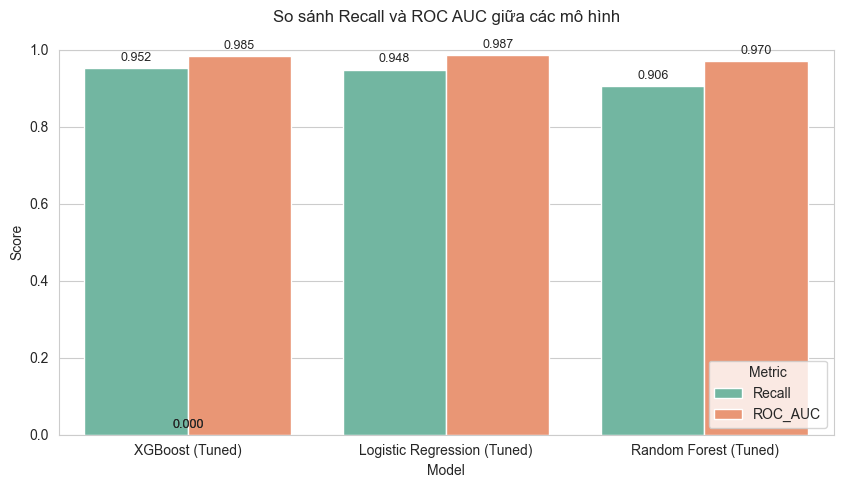

In [50]:
plot_df = results_df.melt(
    id_vars=['Model'],
    value_vars=['Recall', 'ROC_AUC'],
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric', palette='Set2')
plt.ylim(0.0, 1.0)
plt.title('So sánh Recall và ROC AUC giữa các mô hình', pad=20)
plt.ylabel('Score')
plt.xlabel('Model')

for p in ax.patches:
    h = p.get_height()
    ax.annotate(f'{h:.3f}',
                (p.get_x() + p.get_width() / 2., h),
                ha = 'center',
                va = 'bottom',
                fontsize=9,
                xytext=(0, 3),
                textcoords='offset points')
plt.legend(title='Metric')
plt.show()